# Weather Trend Forecasting

# Introduction

Weather forecasting plays a critical role in multiple domains, including transportation, agriculture, environmental monitoring, energy management, and public safety. Accurate temperature prediction enables better decision-making and helps organizations anticipate climate-related conditions and risks.

This project analyzes the **Global Weather Repository** dataset, which contains weather observations from cities around the world, including atmospheric, geographical, temporal, and air quality variables. The main objective is to forecast future temperature trends using machine learning techniques while exploring the relationships between weather conditions, geographical location, and environmental factors. :contentReference[oaicite:0]{index=0}

The project includes:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Temporal feature engineering
- Outlier and anomaly analysis
- Spatial and climate analysis
- Forecasting model development and comparison
- Feature importance interpretation

Machine learning models were implemented and evaluated, including:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

Special attention was given to preventing data leakage by using temporal train-validation-test splits and fitting preprocessing transformations exclusively on the training set.

The final results demonstrate that temporal dependencies, particularly lag-based features, are highly influential in weather forecasting tasks. Among the evaluated models, XGBoost achieved the best predictive performance, significantly improving forecasting accuracy over simpler baseline approaches.

This project was developed as part of the PM Accelerator Weather Trend Forecasting assessment and aims to showcase practical data science skills across preprocessing, feature engineering, forecasting, visualization, and model evaluation.

# Preprocessing - Data Analysis

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(
    str(Path().resolve().parent)
)
import src.preprocessing as pp
import src.utils as ut

## First Aproach to Data

This section focuses on understanding the nature and structure of the dataset before applying any preprocessing or modeling techniques. An initial inspection was performed to identify the available features, their meanings, data types, scales, and potential relevance for the forecasting task.

Special attention was given to:
- Understanding how weather variables were represented
- Detecting categorical, numerical, temporal, and geographical features
- Identifying potentially redundant or leakage-prone variables
- Checking missing values and duplicated observations
- Analyzing the distributions and ranges of the variables
- Evaluating which features would require preprocessing, encoding, scaling, or transformation

This first exploratory step was essential to design an appropriate preprocessing pipeline and ensure that the subsequent analyses and forecasting models were built on a solid understanding of the data.

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/GlobalWeatherRepository.csv")

print(df.shape)

df.head()

(141898, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
df.info()
df.columns.tolist()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 141898 entries, 0 to 141897
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       141898 non-null  str    
 1   location_name                 141898 non-null  str    
 2   latitude                      141898 non-null  float64
 3   longitude                     141898 non-null  float64
 4   timezone                      141898 non-null  str    
 5   last_updated_epoch            141898 non-null  int64  
 6   last_updated                  141898 non-null  str    
 7   temperature_celsius           141898 non-null  float64
 8   temperature_fahrenheit        141898 non-null  float64
 9   condition_text                141898 non-null  str    
 10  wind_mph                      141898 non-null  float64
 11  wind_kph                      141898 non-null  float64
 12  wind_degree                   141898 non-null  int64  


country                         0
feels_like_fahrenheit           0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
air_quality_Sulphur_dioxide     0
air_quality_PM2.5               0
air_quality_PM10                0
air_quality_us-epa-index        0
air_quality_gb-defra-index      0
sunrise                         0
sunset                          0
moonrise                        0
moonset                         0
moon_phase                      0
visibility_km                   0
feels_like_celsius              0
location_name                   0
cloud                           0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fa

### Basic Modifications

In [4]:
df.duplicated().sum()
df["last_updated"] = pd.to_datetime(df["last_updated"])

print(df["last_updated"].min())
print(df["last_updated"].max())

2024-05-16 01:45:00
2026-05-17 19:15:00


In [5]:
columns_to_drop = [
    "temperature_fahrenheit",
    "wind_mph",
    "pressure_in",
    "precip_in",
    "feels_like_fahrenheit",
    "visibility_miles",
    "gust_mph",
    "last_updated_epoch",
]

df = df.drop(columns=columns_to_drop)

print(df.shape)

(141898, 33)


In [6]:
df = df.drop(columns=["feels_like_celsius"])

df["last_updated"] = pd.to_datetime(df["last_updated"])

df = pp.sort_temporal_data(df)

df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["hour"] = df["last_updated"].dt.hour
df["day_of_week"] = df["last_updated"].dt.dayofweek

In [7]:
print(df.duplicated().sum())

0


## Visual Analysis

### Temperature Distribution

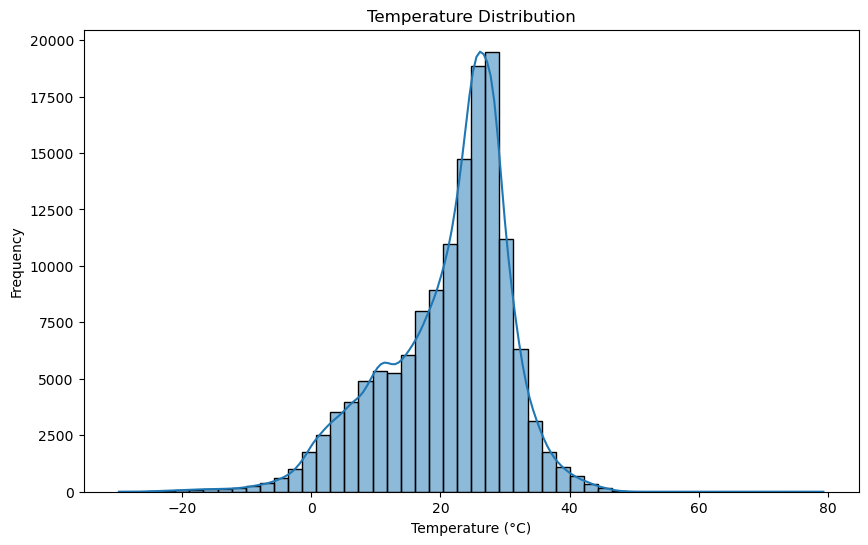

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(df["temperature_celsius"], bins=50, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

### Global temp evolution

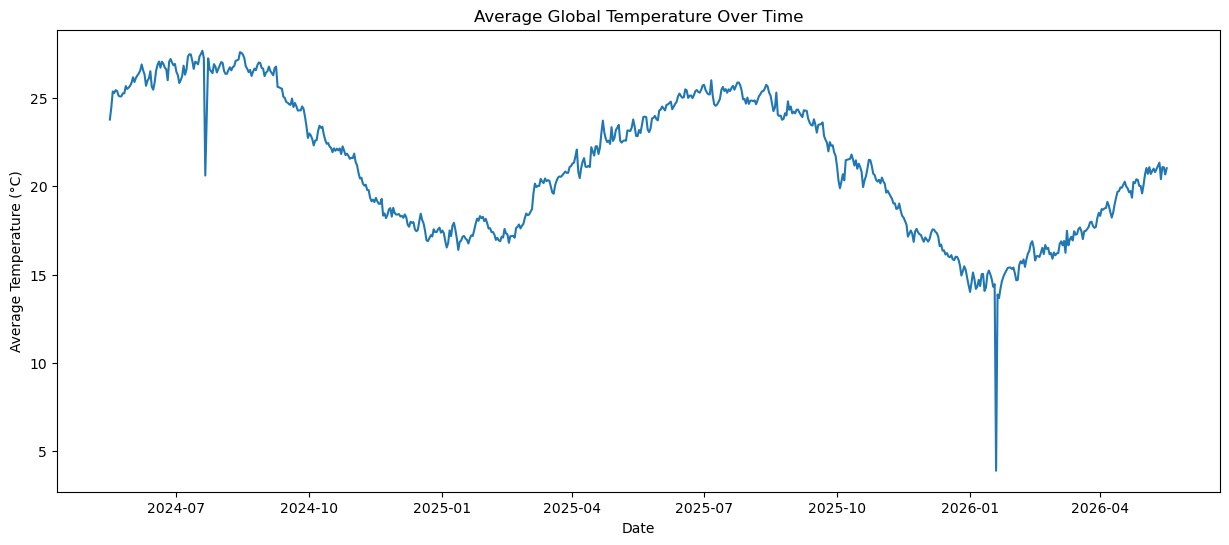

In [9]:
daily_temp = (
    df.groupby(df["last_updated"].dt.date)["temperature_celsius"]
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(daily_temp.index, daily_temp.values)

plt.title("Average Global Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Average Temperature (°C)")

plt.show()

During EDA, anomalous global average temperature drops were detected, suggesting potential outliers or sampling inconsistencies requiring preprocessing.

### Features correlation 

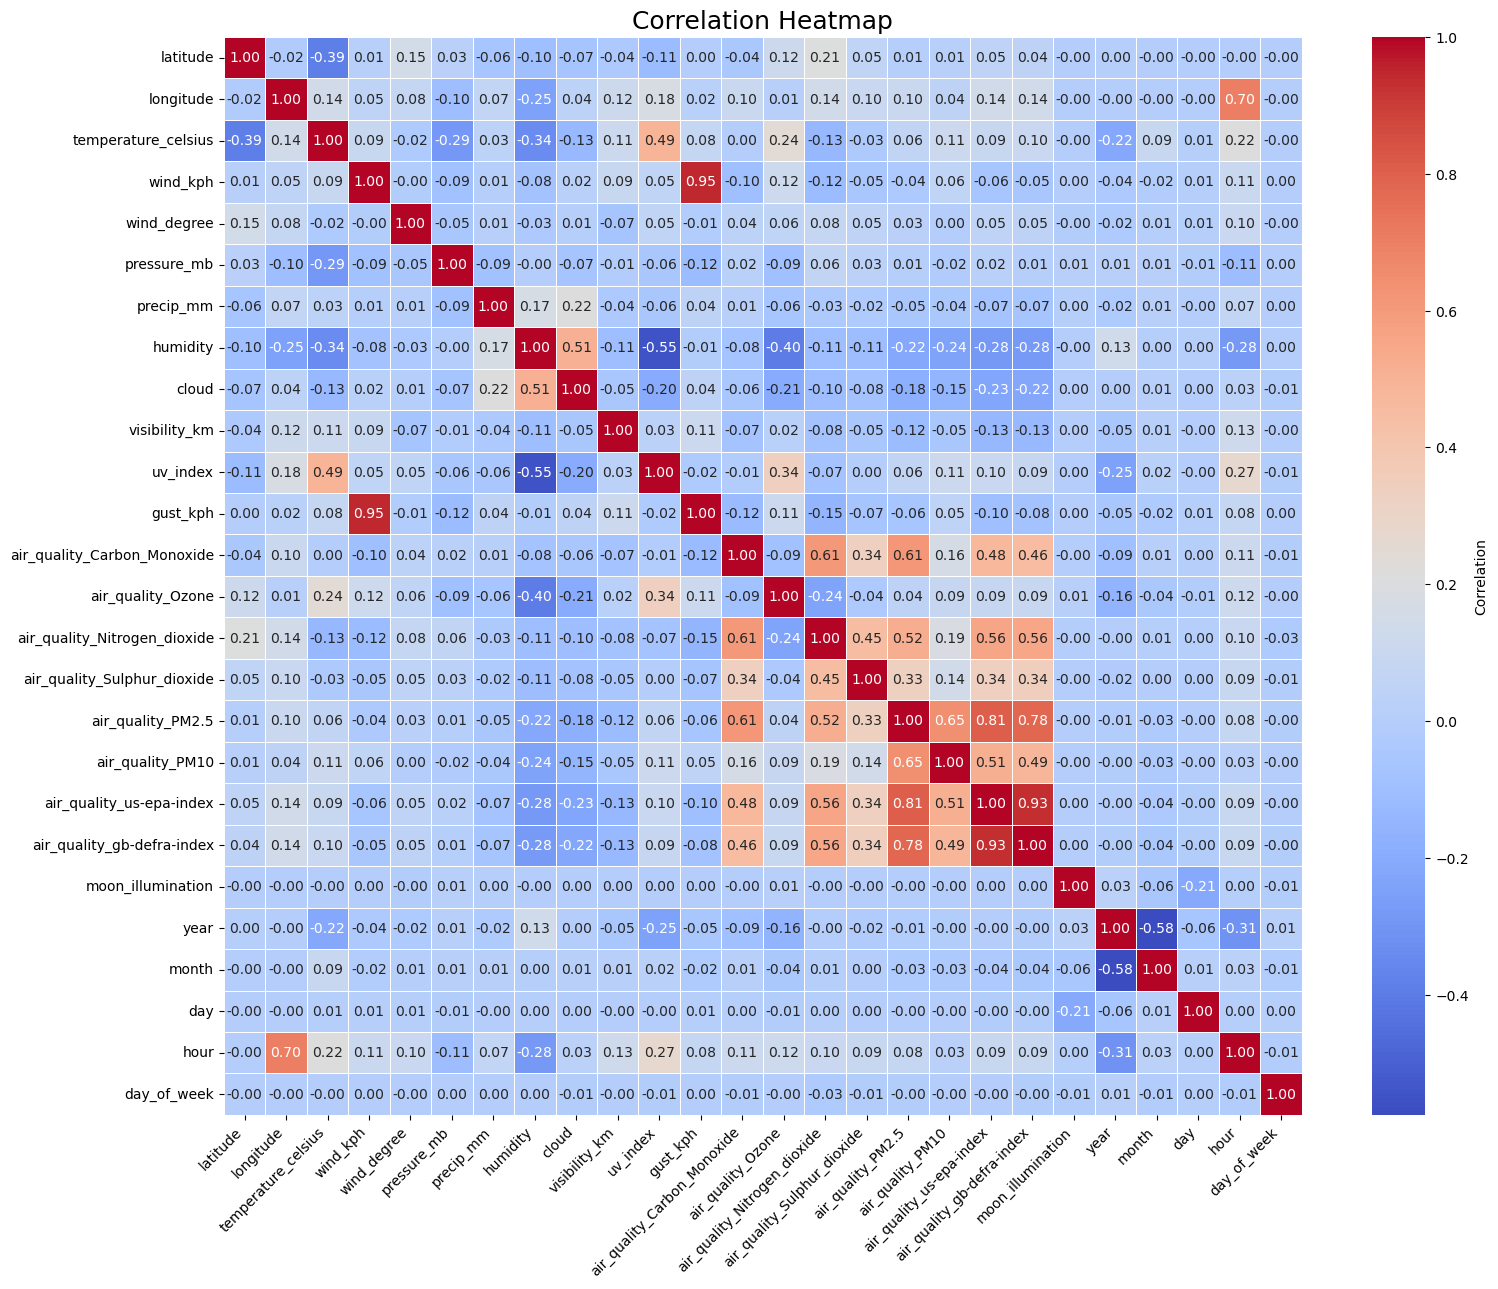

In [10]:
numeric_df = df.select_dtypes(include=["int64", "float64", "int32"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap", fontsize=18)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

### Top Countries

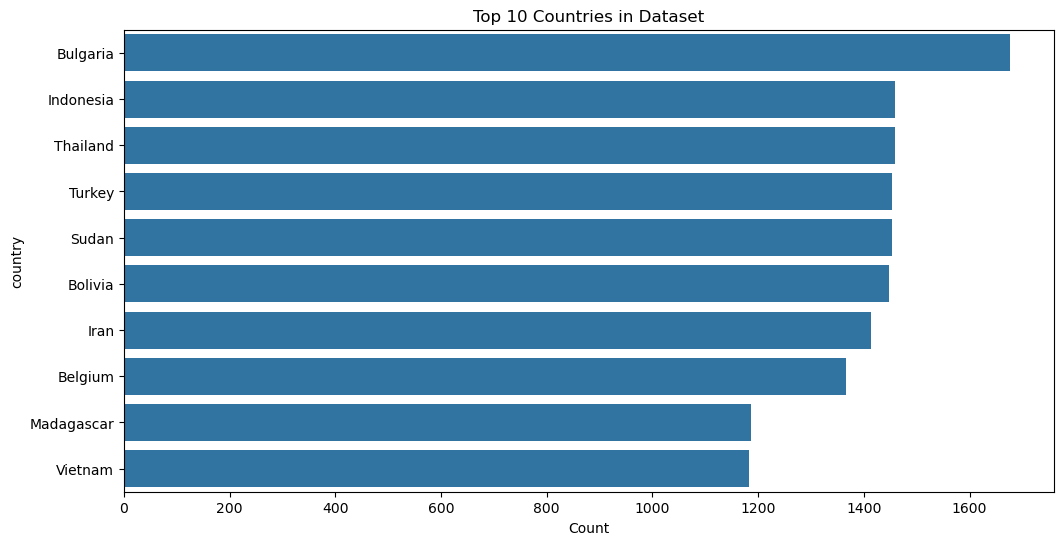

In [11]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries in Dataset")
plt.xlabel("Count")

plt.show()

### Temperature by month

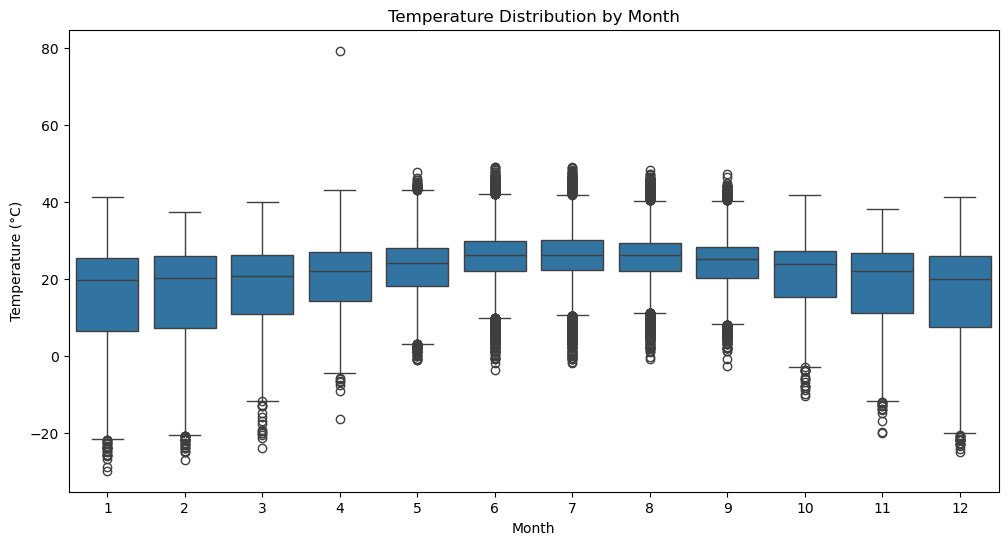

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df["month"],
    y=df["temperature_celsius"]
)

plt.title("Temperature Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.show()

### Observation
Temperatures exhibit strong seasonality patterns, with higher medians during mid-year months and lower dispersion during colder periods.

### Implication
Temporal features such as month and day-of-year are likely to be predictive for forecasting tasks.

### Basic Improvement

In [13]:
df = pp.add_cyclical_features(df)

df = pp.add_lag_features(df)

df = df.dropna().reset_index(drop=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 136573 entries, 0 to 136572
Data columns (total 47 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       136573 non-null  str           
 1   location_name                 136573 non-null  str           
 2   latitude                      136573 non-null  float64       
 3   longitude                     136573 non-null  float64       
 4   timezone                      136573 non-null  str           
 5   last_updated                  136573 non-null  datetime64[us]
 6   temperature_celsius           136573 non-null  float64       
 7   condition_text                136573 non-null  str           
 8   wind_kph                      136573 non-null  float64       
 9   wind_degree                   136573 non-null  int64         
 10  wind_direction                136573 non-null  str           
 11  pressure_mb             

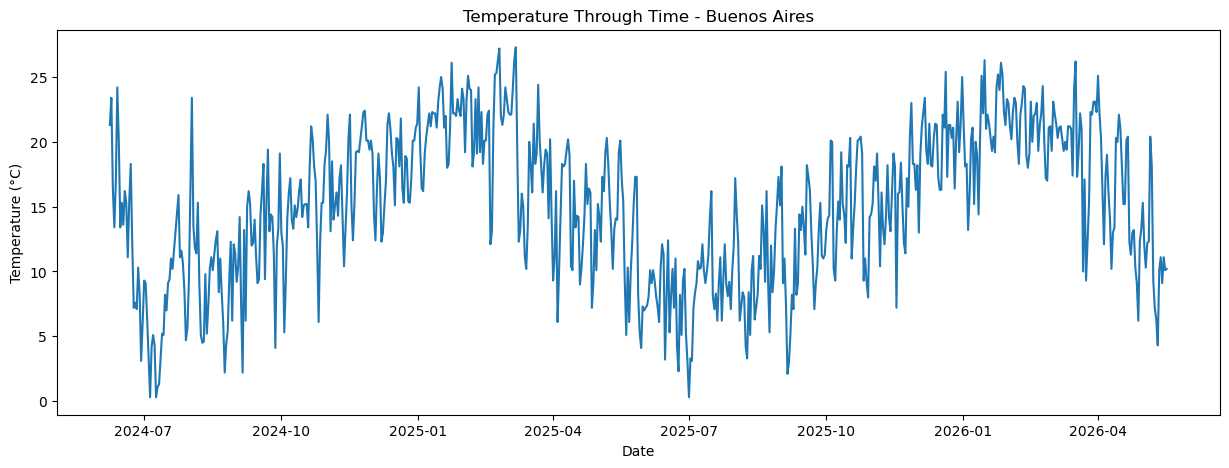

In [14]:
city_df = df[df["location_name"] == "Buenos Aires"]

plt.figure(figsize=(15,5))

plt.plot(
    city_df["last_updated"],
    city_df["temperature_celsius"]
)

plt.title("Temperature Through Time - Buenos Aires")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.show()

Plotted temperature through time to analyze temporal patterns in the dataset, such as seasonality, trends, and fluctuations in temperature values over time. This type of visualization helps verify whether temporal feature engineering techniques like lag features and cyclical encoding are meaningful for the forecasting task.


The plot was generated using only one city (Buenos Aires) as an example because combining all cities in a single time series creates excessive visual noise and connects unrelated observations from different locations. By focusing on a single city, the temporal behavior becomes much clearer and easier to interpret.

## Data Modification - Numeric

### General

In [15]:
physical_checks = [
    {"column": "humidity", "type": "range", "min": 0, "max": 100},
    {"column": "cloud", "type": "range", "min": 0, "max": 100},
    {"column": "pressure_mb", "type": "min", "value": 0},
    {"column": "visibility_km", "type": "min", "value": 0},

    {
        "column": "temperature_celsius",
        "type": "range",
        "min": -90,
        "max": 60,
    },

    {"column": "wind_kph", "type": "min", "value": 0},
    {"column": "gust_kph", "type": "min", "value": 0},

    {
        "column": "wind_degree",
        "type": "range",
        "min": 0,
        "max": 360,
    },

    {"column": "precip_mm", "type": "min", "value": 0},
    {"column": "uv_index", "type": "min", "value": 0},

    {
        "column": "air_quality_Carbon_Monoxide",
        "type": "min",
        "value": 0,
    },

    {
        "column": "air_quality_Ozone",
        "type": "min",
        "value": 0,
    },

    {
        "column": "air_quality_Nitrogen_dioxide",
        "type": "min",
        "value": 0,
    },

    {
        "column": "air_quality_Sulphur_dioxide",
        "type": "min",
        "value": 0,
    },

    {
        "column": "air_quality_PM2.5",
        "type": "min",
        "value": 0,
    },

    {
        "column": "air_quality_PM10",
        "type": "min",
        "value": 0,
    },

    {
        "column": "air_quality_us-epa-index",
        "type": "range",
        "min": 1,
        "max": 6,
    },

    {
        "column": "air_quality_gb-defra-index",
        "type": "range",
        "min": 1,
        "max": 10,
    },

    {
        "column": "moon_illumination",
        "type": "range",
        "min": 0,
        "max": 100,
    },

    {
        "column": "month",
        "type": "range",
        "min": 1,
        "max": 12,
    },

    {
        "column": "day",
        "type": "range",
        "min": 1,
        "max": 31,
    },

    {
        "column": "hour",
        "type": "range",
        "min": 0,
        "max": 23,
    },

    {
        "column": "day_of_week",
        "type": "range",
        "min": 0,
        "max": 6,
    },

    {
        "column": "latitude",
        "type": "range",
        "min": -90,
        "max": 90,
    },

    {
        "column": "longitude",
        "type": "range",
        "min": -180,
        "max": 180,
    },
]

impossible_df = pp.run_physical_checks(
    df,
    physical_checks,
)

impossible_df[impossible_df["count"] > 0]

,check,count
0,air_quality_PM10 < 0,2
1,"temperature_celsius outside [-90, 60]",1
2,air_quality_Carbon_Monoxide < 0,1
3,air_quality_Sulphur_dioxide < 0,1


In [16]:
# Remove physically impossible observations detected during EDA
df = df[
    (df["temperature_celsius"].between(-90, 60)) &
    (df["air_quality_Carbon_Monoxide"] >= 0) &
    (df["air_quality_Sulphur_dioxide"] >= 0) &
    (df["air_quality_PM10"] >= 0) 
].reset_index(drop=True)


In [17]:
df["is_raining"] = (df["precip_mm"] > 0).astype(int)

### Split

In [18]:
train_df, val_df, test_df = pp.temporal_train_val_test_split(df)

In [19]:
print(train_df["last_updated"].min(), train_df["last_updated"].max())
print(val_df["last_updated"].min(), val_df["last_updated"].max())
print(test_df["last_updated"].min(), test_df["last_updated"].max())

2024-06-08 08:15:00 2025-09-04 18:00:00
2025-09-04 19:00:00 2025-12-26 09:15:00
2025-12-26 09:15:00 2026-05-17 19:15:00


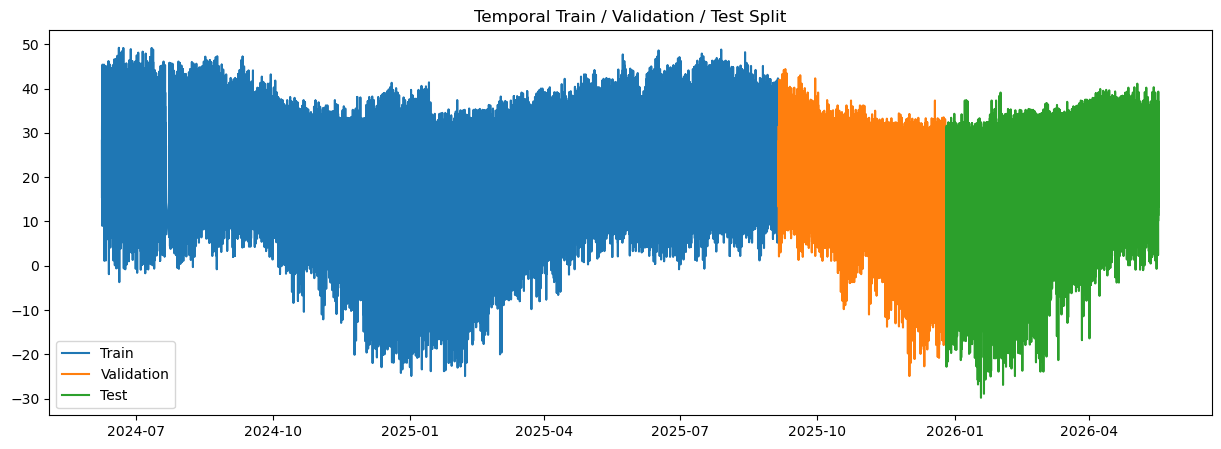

In [20]:
plt.figure(figsize=(15,5))

plt.plot(train_df["last_updated"], train_df["temperature_celsius"], label="Train")
plt.plot(val_df["last_updated"], val_df["temperature_celsius"], label="Validation")
plt.plot(test_df["last_updated"], test_df["temperature_celsius"], label="Test")

plt.legend()
plt.title("Temporal Train / Validation / Test Split")

plt.show()

---------------------------------------------------------------------------------------------------------------------------------------

### Outliers

In [21]:
outlier_df = pp.detect_outliers_iqr(train_df)

outlier_df

,feature,lower_bound,upper_bound,outliers,percentage
0,visibility_km,10.000000,10.000000,16719,19.128634
1,precip_mm,-0.045000,0.075000,16400,18.763658
2,air_quality_Sulphur_dioxide,-11.902500,22.237500,11834,13.539581
3,air_quality_gb-defra-index,-2.000000,6.000000,10010,11.452696
4,air_quality_Nitrogen_dioxide,-24.222500,43.837500,9683,11.078567
5,air_quality_PM10,-42.540000,101.300000,9343,10.689564
6,air_quality_Carbon_Monoxide,-162.800000,917.600000,7811,8.936764
7,air_quality_us-epa-index,-0.500000,3.500000,7321,8.376143
8,air_quality_PM2.5,-26.775000,65.345000,7321,8.376143
9,pressure_mb,998.000000,1030.000000,2922,3.343135


### Log transforms for skewed features 

In [22]:
train_df, val_df, test_df, safe_log_cols = pp.add_log_features(
    train_df,
    val_df,
    test_df,
)

print("Log-transformed columns:")
print([f"{col}_log" for col in safe_log_cols])


# REMOVE ORIGINAL SKEWED FEATURES

train_df = train_df.drop(columns=safe_log_cols)
val_df = val_df.drop(columns=safe_log_cols)
test_df = test_df.drop(columns=safe_log_cols)

print("\nRemoved original skewed columns:")
print(safe_log_cols)

Log-transformed columns:
['precip_mm_log', 'gust_kph_log', 'wind_kph_log', 'air_quality_PM2.5_log', 'air_quality_PM10_log']

Removed original skewed columns:
['precip_mm', 'gust_kph', 'wind_kph', 'air_quality_PM2.5', 'air_quality_PM10']


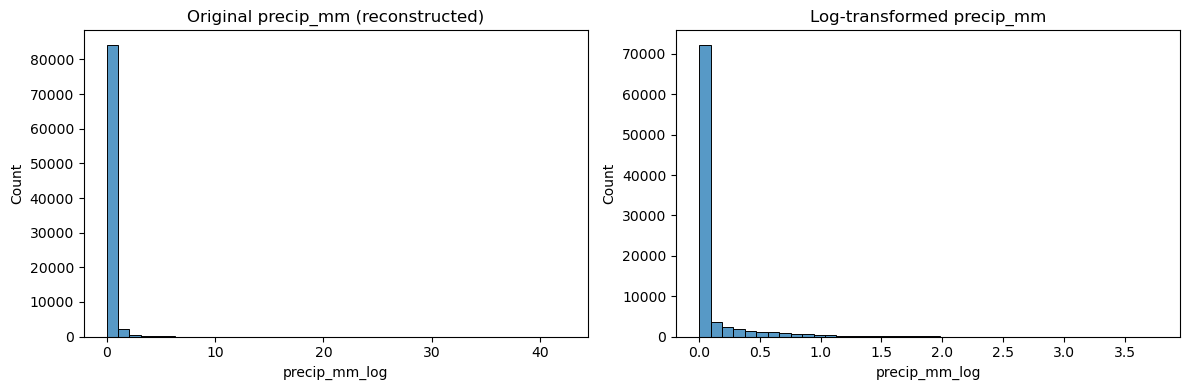

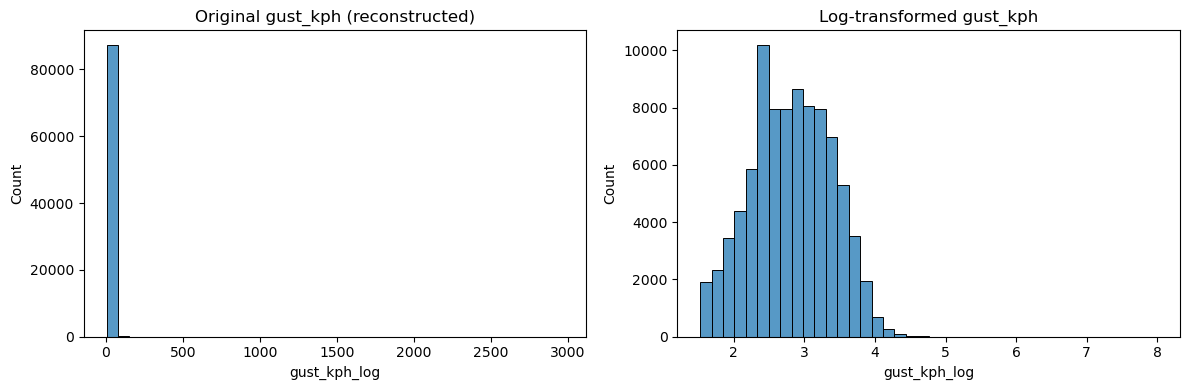

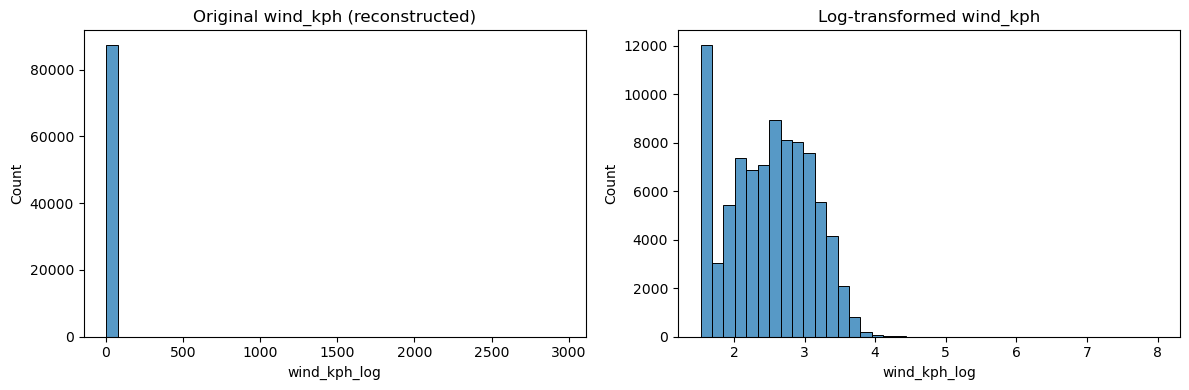

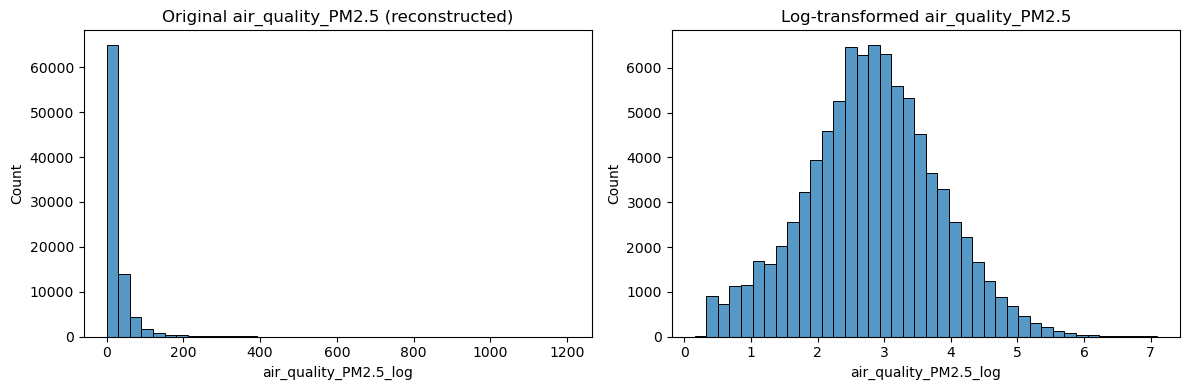

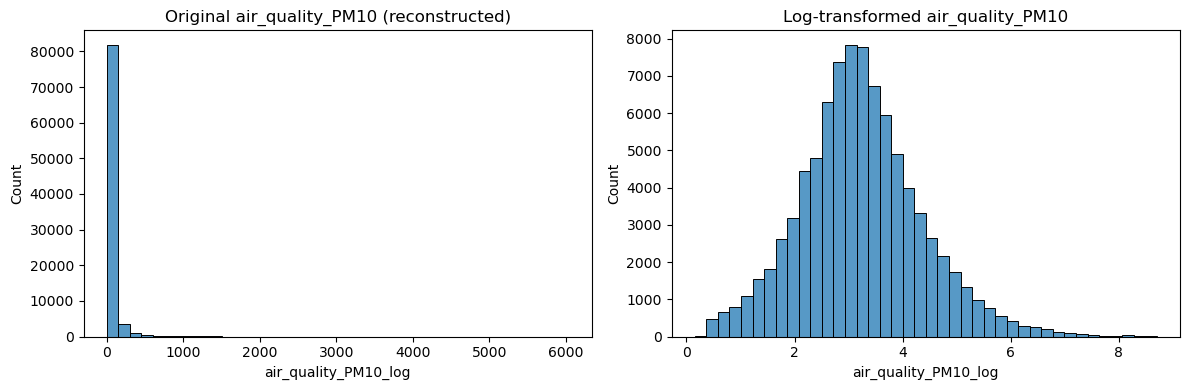

In [23]:
# VISUAL COMPARISON

for col in safe_log_cols:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4),
    )

    sns.histplot(
        np.expm1(train_df[f"{col}_log"]),
        bins=40,
        ax=axes[0],
    )

    axes[0].set_title(
        f"Original {col} (reconstructed)"
    )

    sns.histplot(
        train_df[f"{col}_log"],
        bins=40,
        ax=axes[1],
    )

    axes[1].set_title(
        f"Log-transformed {col}"
    )

    plt.tight_layout()
    plt.show()

---------------------------------------------------------------------------------------------------------------------------------------

## Data Modification - Categorical

In [24]:
categorical_cols = ut.get_categorical_columns(df)

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['country', 'location_name', 'timezone', 'condition_text', 'wind_direction', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase']


### CARDINALITY ANALYSIS

In [25]:
categorical_summary = []

for col in categorical_cols:

    n_unique = df[col].nunique()

    categorical_summary.append({
        "feature": col,
        "unique_values": n_unique,
        "missing_values": df[col].isna().sum(),
        "sample_values": df[col].unique()[:5],
    })

categorical_summary_df = (
    pd.DataFrame(categorical_summary)
    .sort_values("unique_values", ascending=False)
    .reset_index(drop=True)
)

categorical_summary_df

,feature,unique_values,missing_values,sample_values
0,moonrise,1444,0,"[06:39 AM, 07:57 AM, 09:13 AM, 10:26 AM, 11:37..."
1,moonset,1444,0,"[11:33 PM, 11:52 PM, No moonset, 12:05 AM, 12:..."
2,sunset,540,0,"[10:01 PM, 10:00 PM, 09:59 PM, 09:58 PM, 09:56..."
3,sunrise,486,0,"[05:39 AM, 05:40 AM, 05:41 AM, 05:42 AM, 05:43..."
4,location_name,214,0,"['S Gravenjansdijk, 'S-Gravenbrakel, Abu Dhabi..."
5,country,197,0,"[Belgium, United Arab Emirates, Nigeria, Ghana..."
6,timezone,191,0,"[Europe/Brussels, Asia/Dubai, Africa/Lagos, Af..."
7,condition_text,49,0,"[Partly cloudy, Overcast, Light drizzle, Sunny..."
8,wind_direction,16,0,"[SW, W, S, WSW, WNW]"
9,moon_phase,8,0,"[Waxing Crescent, Waxing Gibbous, Waning Gibbo..."


### VALUE COUNTS PER FEATURE

In [26]:
for col in categorical_cols:

    print("=" * 60)
    print(f"FEATURE: {col}")
    print("=" * 60)

    print(f"Unique values: {df[col].nunique()}")
    print()

    display(
        df[col]
        .value_counts(dropna=False)
        .head(15)
    )

    print("\n")

FEATURE: country
Unique values: 197



country
Bulgaria       1604
Thailand       1410
Indonesia      1409
Turkey         1406
Sudan          1406
Bolivia        1399
Iran           1366
Belgium        1266
Madagascar     1139
Vietnam        1109
Hungary         788
Russia          734
Switzerland     729
Ghana           706
Jordan          706
Name: count, dtype: int64



FEATURE: location_name
Unique values: 214



location_name
Accra        706
Amman        706
Asmara       706
Baghdad      706
Bern         706
Bujumbura    706
Dakar        706
Kabul        706
Kyiv         706
Malabo       706
N'djamena    706
Nan          706
Sanaa        706
Tashkent     706
Tokyo        706
Name: count, dtype: int64



FEATURE: timezone
Unique values: 191



timezone
Asia/Bangkok           2501
Europe/Sofia           1592
Europe/Rome            1433
Asia/Jakarta           1409
Europe/Istanbul        1407
Africa/Khartoum        1406
America/La_Paz         1400
Asia/Tehran            1366
Europe/Brussels        1267
Indian/Antananarivo    1139
Africa/Johannesburg    1070
Europe/Zurich          1068
Africa/Brazzaville     1066
Europe/Paris           1042
Africa/Douala          1012
Name: count, dtype: int64



FEATURE: condition_text
Unique values: 49



condition_text
Sunny                                  39393
Partly cloudy                          38216
Patchy rain nearby                     11637
Partly Cloudy                           9058
Overcast                                7468
Clear                                   7360
Mist                                    5769
Light rain                              4290
Light rain shower                       3134
Fog                                     1744
Cloudy                                  1689
Moderate or heavy rain with thunder     1036
Moderate rain                           1012
Patchy light rain with thunder           819
Light drizzle                            699
Name: count, dtype: int64



FEATURE: wind_direction
Unique values: 16



wind_direction
E      12959
ENE    11462
ESE     9402
N       9044
NNE     9040
S       8280
SSW     8075
SW      8047
WSW     8038
NE      8014
SSE     7987
NNW     7856
SE      7244
WNW     7130
W       6998
Name: count, dtype: int64



FEATURE: sunrise
Unique values: 486



sunrise
05:57 AM    1489
06:10 AM    1454
06:11 AM    1450
05:56 AM    1412
05:55 AM    1410
06:17 AM    1409
06:24 AM    1398
06:21 AM    1388
06:07 AM    1371
05:58 AM    1359
05:54 AM    1349
06:06 AM    1349
06:05 AM    1321
06:23 AM    1321
06:15 AM    1315
Name: count, dtype: int64



FEATURE: sunset
Unique values: 540



sunset
06:02 PM    1371
06:17 PM    1283
06:03 PM    1279
06:11 PM    1259
06:19 PM    1252
06:18 PM    1250
06:13 PM    1229
06:28 PM    1218
06:16 PM    1212
06:29 PM    1209
06:35 PM    1208
06:01 PM    1207
06:10 PM    1199
06:12 PM    1188
06:14 PM    1185
Name: count, dtype: int64



FEATURE: moonrise
Unique values: 1444



moonrise
No moonrise    4624
12:00 AM        222
05:52 AM        124
11:45 AM        122
04:16 AM        120
09:27 AM        120
12:51 AM        118
11:39 PM        118
01:05 PM        118
12:35 AM        118
06:15 PM        118
05:05 AM        117
03:48 AM        117
11:44 PM        117
08:28 AM        116
Name: count, dtype: int64



FEATURE: moonset
Unique values: 1444



moonset
No moonset    4627
12:00 AM       238
12:01 AM       129
10:33 AM       125
05:53 PM       124
05:52 AM       123
01:53 AM       119
04:26 AM       118
09:54 PM       117
01:55 AM       117
12:34 PM       116
01:08 AM       116
01:31 PM       116
02:03 AM       116
12:05 AM       115
Name: count, dtype: int64



FEATURE: moon_phase
Unique values: 8



moon_phase
Waning Crescent    29751
Waxing Crescent    29714
Waxing Gibbous     28941
Waning Gibbous     28532
Last Quarter        4947
New Moon            4932
Full Moon           4918
First Quarter       4833
Name: count, dtype: int64

### CATEGORICAL FEATURE ENGINEERING

In [27]:
for dataset_name, dataset in {
    "train": train_df,
    "val": val_df,
    "test": test_df,
}.items():

    dataset = pp.add_sun_time_features(dataset)

    dataset = pp.add_wind_direction_features(dataset)

    if dataset_name == "train":
        train_df = dataset

    elif dataset_name == "val":
        val_df = dataset

    else:
        test_df = dataset


one_hot_cols = [
    "condition_text",
    "moon_phase",
]

train_df = pp.one_hot_encode(
    train_df,
    columns=one_hot_cols,
    drop_first=True,
)

val_df = pp.one_hot_encode(
    val_df,
    columns=one_hot_cols,
    drop_first=True,
)

test_df = pp.one_hot_encode(
    test_df,
    columns=one_hot_cols,
    drop_first=True,
)

val_df = val_df.reindex(
    columns=train_df.columns,
    fill_value=0,
)

test_df = test_df.reindex(
    columns=train_df.columns,
    fill_value=0,
)

In [28]:
# FEATURE ENGINEERING CHECK
train_df[
    [
        "sunrise",
        "sunrise_minutes",
        "sunset",
        "sunset_minutes",
        "wind_direction",
        "wind_direction_degrees",
        "wind_dir_sin",
        "wind_dir_cos",
    ]
].head()

,sunrise,sunrise_minutes,sunset,sunset_minutes,wind_direction,wind_direction_degrees,wind_dir_sin,wind_dir_cos
0,05:20 AM,320,06:28 PM,1108,WNW,292.5,-0.923880,3.826834e-01
1,05:29 AM,329,06:23 PM,1103,N,0.0,0.000000,1.000000e+00
2,05:32 AM,332,06:30 PM,1110,SSW,202.5,-0.382683,-9.238795e-01
3,05:20 AM,320,06:09 PM,1089,N,0.0,0.000000,1.000000e+00
4,05:58 AM,358,07:14 PM,1154,E,90.0,1.000000,6.123234e-17


### DROP HIGH CARDINALITY FEATURES

In [29]:
drop_cols = [
    "location_name",
    "timezone",
    "moonrise",
    "moonset",
]

train_df = train_df.drop(columns=drop_cols)

val_df = val_df.drop(columns=drop_cols)

test_df = test_df.drop(columns=drop_cols)

In [30]:
# CHECK COLUMN ALIGNMENT

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

print(train_df.columns.equals(val_df.columns))
print(train_df.columns.equals(test_df.columns))

(87403, 100)
(21851, 100)
(27314, 100)
True
True


### DROP REDUNDANT FEATURES

In [31]:
redundant_cols = [
    "sunrise",
    "sunset",
    "wind_direction",
    "wind_direction_degrees",
]

train_df = train_df.drop(columns=redundant_cols)

val_df = val_df.drop(columns=redundant_cols)

test_df = test_df.drop(columns=redundant_cols)

### COUNTRY DISTRIBUTION ANALYSIS

In [32]:
country_stats = (
    train_df["country"]
    .value_counts()
    .reset_index()
)

country_stats.columns = [
    "country",
    "samples",
]

country_stats["percentage"] = (
    country_stats["samples"] / len(train_df) * 100
)

country_stats.head(20)

,country,samples,percentage
0,Bulgaria,923,1.056028
1,Indonesia,903,1.033145
2,Sudan,902,1.032001
3,Iran,902,1.032001
4,Turkey,901,1.030857
5,Thailand,901,1.030857
6,Bolivia,895,1.023992
7,Madagascar,886,1.013695
8,Belgium,858,0.981660
9,Vietnam,838,0.958777



### COUNTRY BALANCE SUMMARY


In [33]:
country_stats["samples"].describe()

count    196.000000
mean     445.933673
std      146.409159
min        1.000000
25%      449.000000
50%      451.000000
75%      452.000000
max      923.000000
Name: samples, dtype: float64

### UNDERREPRESENTED COUNTRIES

In [34]:
min_samples_threshold = 300

rare_countries = country_stats[
    country_stats["samples"] < min_samples_threshold
]

print(f"Countries with fewer than {min_samples_threshold} samples:")
print(len(rare_countries))

rare_countries

Countries with fewer than 300 samples:
11


,country,samples,percentage
185,USA United States of America,1,0.001144
186,Saint-Vincent-et-les-Grenadines,1,0.001144
187,Bélgica,1,0.001144
188,Польша,1,0.001144
189,Турция,1,0.001144
190,Estonie,1,0.001144
191,Letonia,1,0.001144
192,Komoren,1,0.001144
193,Jemen,1,0.001144
194,Inde,1,0.001144


### REMOVE RARE COUNTRY ENTRIES

In [35]:
valid_countries = country_stats[
    country_stats["samples"] >= min_samples_threshold
]["country"]

train_df = train_df[
    train_df["country"].isin(valid_countries)
]

val_df = val_df[
    val_df["country"].isin(valid_countries)
]

test_df = test_df[
    test_df["country"].isin(valid_countries)
]

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)



### COUNTRY DISTRIBUTION PLOT

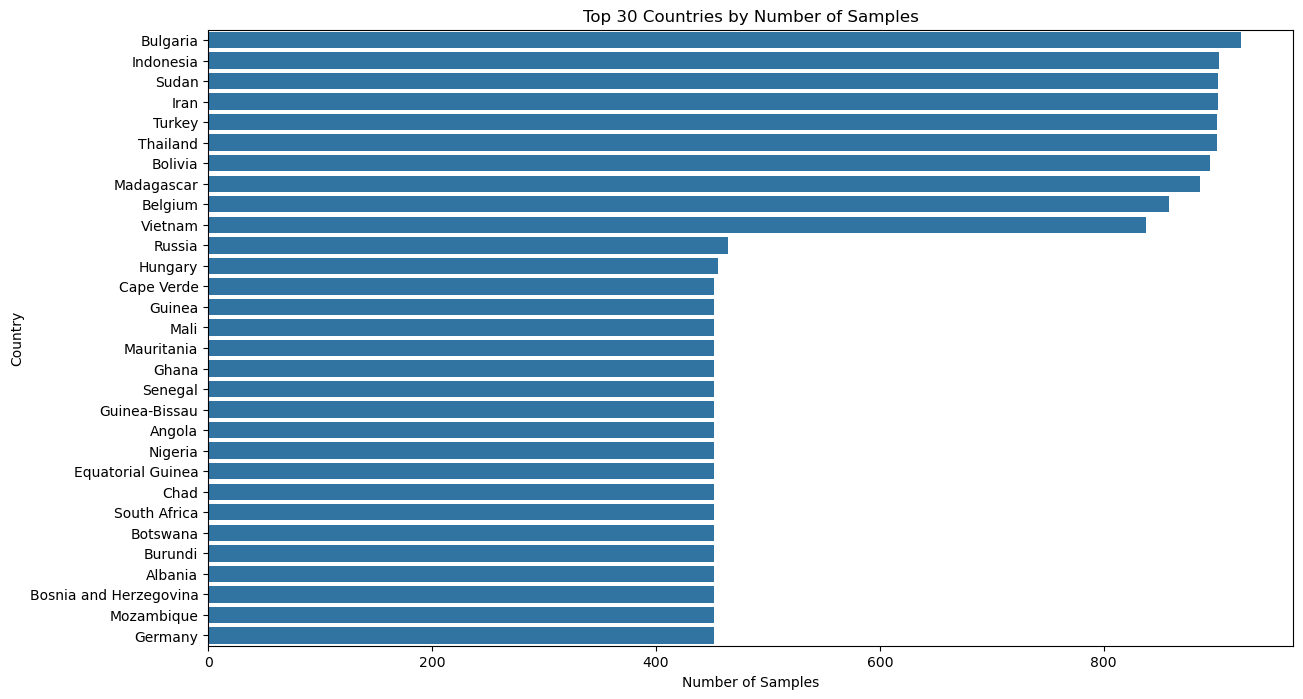

In [36]:
top_n = 30

top_countries = country_stats.head(top_n)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top_countries,
    x="samples",
    y="country",
)

plt.title(f"Top {top_n} Countries by Number of Samples")
plt.xlabel("Number of Samples")
plt.ylabel("Country")

plt.show()

### COUNTRY FREQUENCY HISTOGRAM

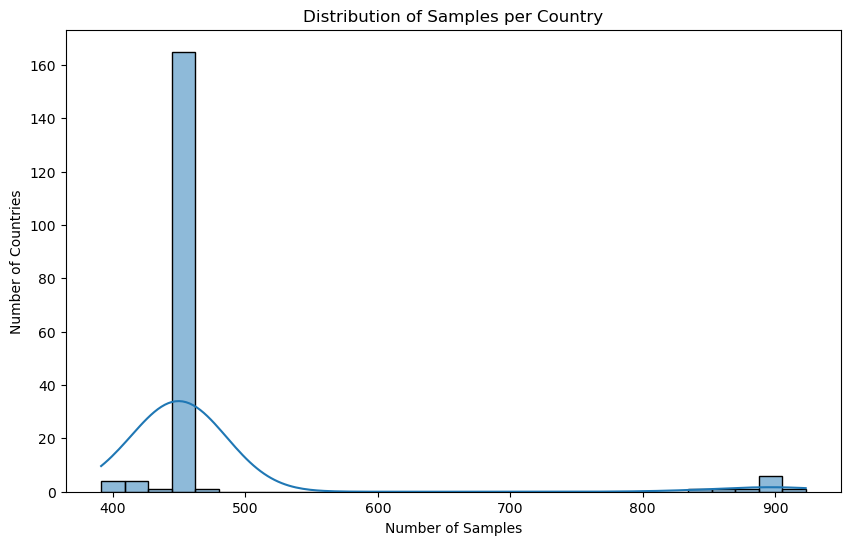

In [37]:
country_stats = (
    train_df["country"]
    .value_counts()
    .reset_index()
)

country_stats.columns = [
    "country",
    "samples",
]

country_stats["percentage"] = (
    country_stats["samples"] / len(train_df) * 100
)

country_stats.head(20)

plt.figure(figsize=(10, 6))

sns.histplot(
    country_stats["samples"],
    bins=30,
    kde=True,
)

plt.title("Distribution of Samples per Country")
plt.xlabel("Number of Samples")
plt.ylabel("Number of Countries")

plt.show()

### FREQUENCY ENCODING

In [38]:
frequency_cols = [
    "country",
]

(
    train_df,
    val_df,
    test_df,
    encoding_maps,
) = pp.frequency_encode(
    train_df,
    val_df,
    test_df,
    columns=frequency_cols,
)

### FREQUENCY ENCODING CHECK

In [39]:
train_df[
    [
        "country",
        "country_freq",
    ]
].head()

,country,country_freq
0,Belize,0.005126
1,El Salvador,0.005103
2,Guatemala,0.005103
3,Nicaragua,0.005115
4,Mexico,0.005115


### DROP ORIGINAL CATEGORICALS

In [40]:
categorical_drop_cols = [
    "country",
]

train_df = train_df.drop(columns=categorical_drop_cols)

val_df = val_df.drop(columns=categorical_drop_cols)

test_df = test_df.drop(columns=categorical_drop_cols)

## DATA TYPES SUMMARY

In [41]:
train_df.dtypes.value_counts()


# REMAINING NON NUMERIC FEATURES
non_numeric_cols = train_df.select_dtypes(
    exclude=["int64", "float64", "bool"]
).columns.tolist()

print("Remaining non-numeric columns:")
print(non_numeric_cols)


# SHAPE + MISSING VALUES CHECK
print("TRAIN SHAPE:", train_df.shape)
print("VAL SHAPE:", val_df.shape)
print("TEST SHAPE:", test_df.shape)

print("\nMissing values:")

print(
    train_df
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)



Remaining non-numeric columns:
['last_updated', 'year', 'month', 'day', 'hour', 'day_of_week']
TRAIN SHAPE: (87392, 96)
VAL SHAPE: (21747, 96)
TEST SHAPE: (27174, 96)

Missing values:
latitude                                                      0
longitude                                                     0
condition_text_Partly Cloudy                                  0
condition_text_Overcast                                       0
condition_text_Moderate snow                                  0
condition_text_Moderate rain at times                         0
condition_text_Moderate rain                                  0
condition_text_Moderate or heavy snow showers                 0
condition_text_Moderate or heavy snow in area with thunder    0
condition_text_Moderate or heavy sleet                        0
condition_text_Moderate or heavy rain with thunder            0
condition_text_Moderate or heavy rain shower                  0
condition_text_Moderate or heavy rain in area wi

In [42]:
# REMAINING DATETIME COLUMNS
datetime_cols = train_df.select_dtypes(
    include=["datetime64"]
).columns.tolist()

print(datetime_cols)

['last_updated']


In [43]:
# DROP RAW DATETIME COLUMNS
datetime_drop_cols = [
    "last_updated",
]

train_df = train_df.drop(columns=datetime_drop_cols)

val_df = val_df.drop(columns=datetime_drop_cols)

test_df = test_df.drop(columns=datetime_drop_cols)


# FINAL DATA TYPES CHECK
train_df.dtypes.value_counts()

bool       53
float64    28
int64       9
int32       5
Name: count, dtype: int64

## Normalization 

In [44]:
scaling_config = {
    "standard": [
        "latitude",
        "longitude",
        "pressure_mb",
        "humidity",
        "cloud",
        "moon_illumination",
        "sunrise_minutes",
        "sunset_minutes",
        "wind_degree",
        "temp_lag_1",
        "temp_lag_3",
        "temp_lag_24",
        "temp_roll_3",
        "air_quality_Carbon_Monoxide",
        "air_quality_Ozone",
        "air_quality_Nitrogen_dioxide",
        "air_quality_Sulphur_dioxide",
    ],

    "minmax": [
        "uv_index",
        "visibility_km",
        "air_quality_us-epa-index",
        "air_quality_gb-defra-index",
    ]
}

In [45]:
train_df, val_df, test_df, scaler_stats = pp.scale_features(
    train_df,
    val_df,
    test_df,
    scaling_config=scaling_config,
)

In [46]:
scaled_cols = [
    col
    for columns in scaling_config.values()
    for col in columns
]

train_df[scaled_cols].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
latitude,1.375685e-16,1.000000,-2.470361,1.826566
longitude,-6.959728e-17,1.000000,-3.002769,2.388216
pressure_mb,-2.706489e-15,1.000000,-5.653242,168.113642
humidity,-1.489512e-16,1.000000,-2.560189,1.482360
cloud,-5.853977e-17,1.000000,-1.164417,1.789276
moon_illumination,-1.300884e-17,1.000000,-1.416310,1.445390
sunrise_minutes,3.148139e-16,1.000000,-4.240521,5.803974
sunset_minutes,-8.247603e-16,1.000000,-3.260835,4.456589
wind_degree,-5.203535e-17,1.000000,-1.648923,1.836678
temp_lag_1,6.400348e-16,1.000000,-5.234710,2.927878


---------------------------------------------------------------------------------------------------------------------------------------

# Models

## Imports

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
from src import metrics as mt


## Target

In [48]:
TARGET = "temperature_celsius"

## Features

In [49]:
FEATURES = [
    col
    for col in train_df.columns
    if col != TARGET
]

## Split

In [50]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

## Linear Regression Model

In [51]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### VALIDATION PREDICTIONS

In [52]:
y_val_pred_linear = linear_model.predict(X_val)

### EVALUATION

In [53]:
linear_results = mt.evaluate_regression_model(
    "Linear Regression",
    y_val,
    y_val_pred_linear,
)

linear_results

{'model': 'Linear Regression',
 'MAE': 1.6189190854480269,
 'RMSE': 2.2224488811549437,
 'R2': 0.9400789000083968}

## Random Forest

In [54]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### VALIDATION PREDICTIONS

In [55]:
y_val_pred_rf = rf_model.predict(X_val)

### EVALUATION


In [56]:
rf_results = mt.evaluate_regression_model(
    "Random Forest",
    y_val,
    y_val_pred_rf,
)

rf_results

{'model': 'Random Forest',
 'MAE': 1.431488266891399,
 'RMSE': 2.051770747428457,
 'R2': 0.9489290562145634}

## XGBoost

In [57]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### VALIDATION PREDICTIONS

In [58]:
y_val_pred_xgb = xgb_model.predict(X_val)

### EVALUATION

In [59]:
xgb_results = mt.evaluate_regression_model(
    "XGBoost",
    y_val,
    y_val_pred_xgb,
)

xgb_results

{'model': 'XGBoost',
 'MAE': 1.3257194689960465,
 'RMSE': 1.8867675846782421,
 'R2': 0.9568130007748332}

## Comparison

### Results Table

In [60]:
results = []

results.append(linear_results)
results.append(rf_results)
results.append(xgb_results)

results_df = pd.DataFrame(results)

results_df

,model,MAE,RMSE,R2
0,Linear Regression,1.618919,2.222449,0.940079
1,Random Forest,1.431488,2.051771,0.948929
2,XGBoost,1.325719,1.886768,0.956813


### Graphic

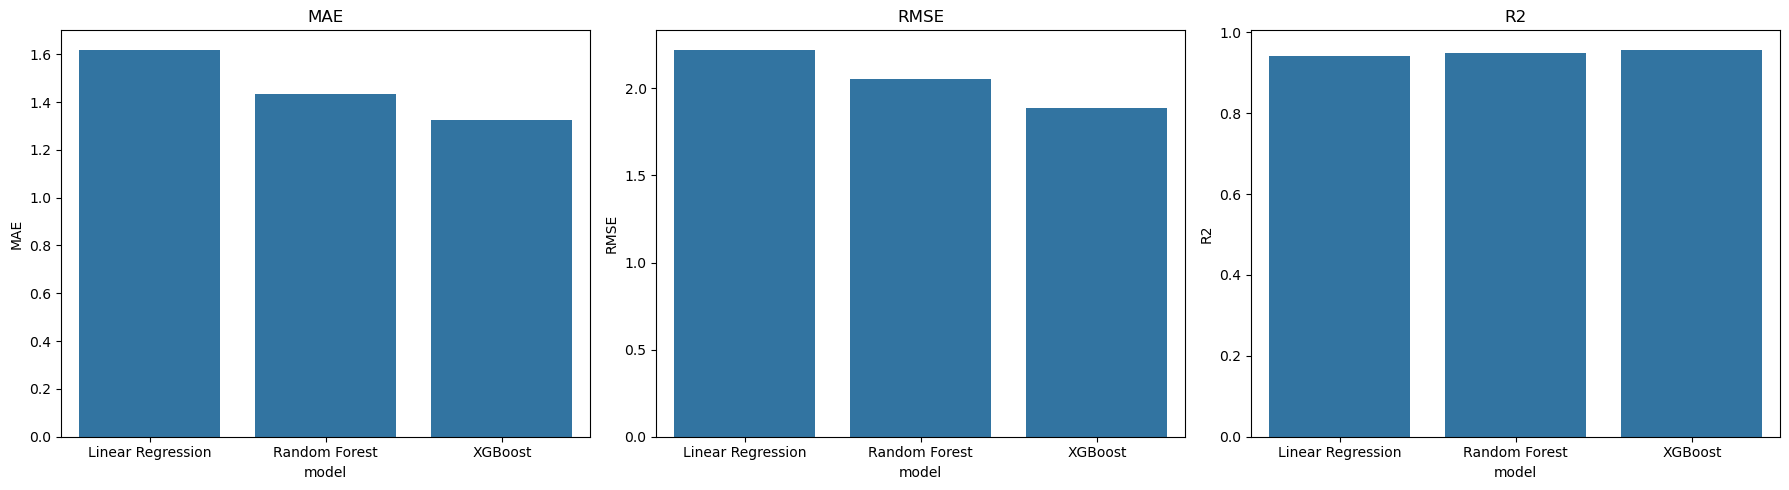

In [61]:
metrics_to_plot = ["MAE", "RMSE", "R2"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):

    sns.barplot(
        data=results_df,
        x="model",
        y=metric,
        ax=ax,
    )

    ax.set_title(metric)

plt.tight_layout()
plt.show()

### PREDICTED VS ACTUAL (XGBoost)

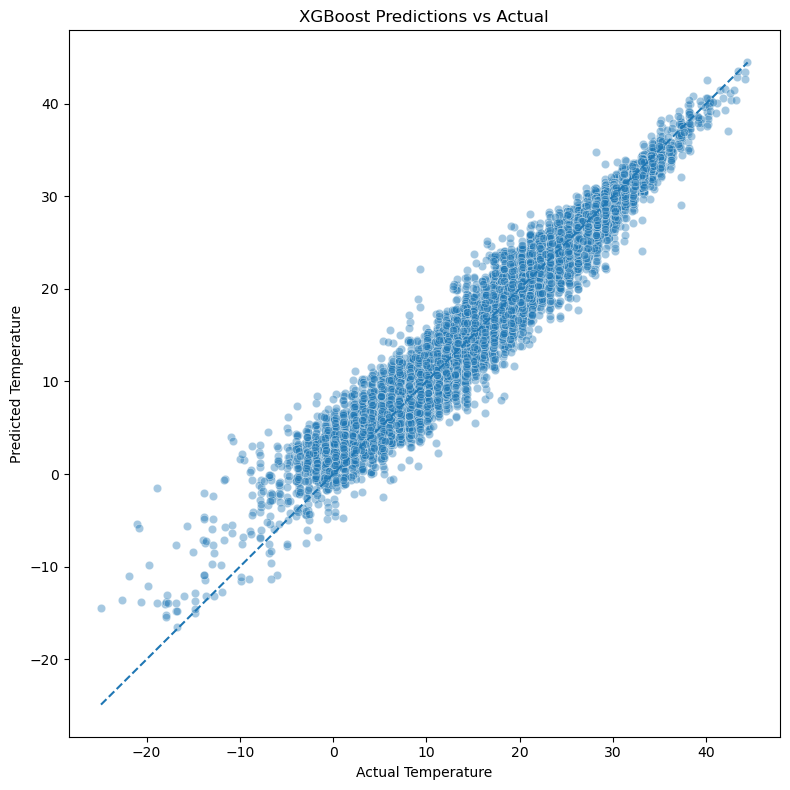

In [62]:
plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_val,
    y=y_val_pred_xgb,
    alpha=0.4,
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("XGBoost Predictions vs Actual")

min_val = min(y_val.min(), y_val_pred_xgb.min())
max_val = max(y_val.max(), y_val_pred_xgb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
)

plt.tight_layout()
plt.show()

## FEATURE IMPORTANCE

In [63]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_,
})

feature_importance_df = (
    feature_importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(15)

,feature,importance
0,temp_lag_1,0.865559
1,temp_roll_3,0.079555
2,humidity,0.012584
3,pressure_mb,0.004244
4,latitude,0.003680
5,temp_lag_24,0.003517
6,uv_index,0.003364
7,sunset_minutes,0.002096
8,sunrise_minutes,0.001687
9,temp_lag_3,0.001639


### TOP FEATURE IMPORTANCE

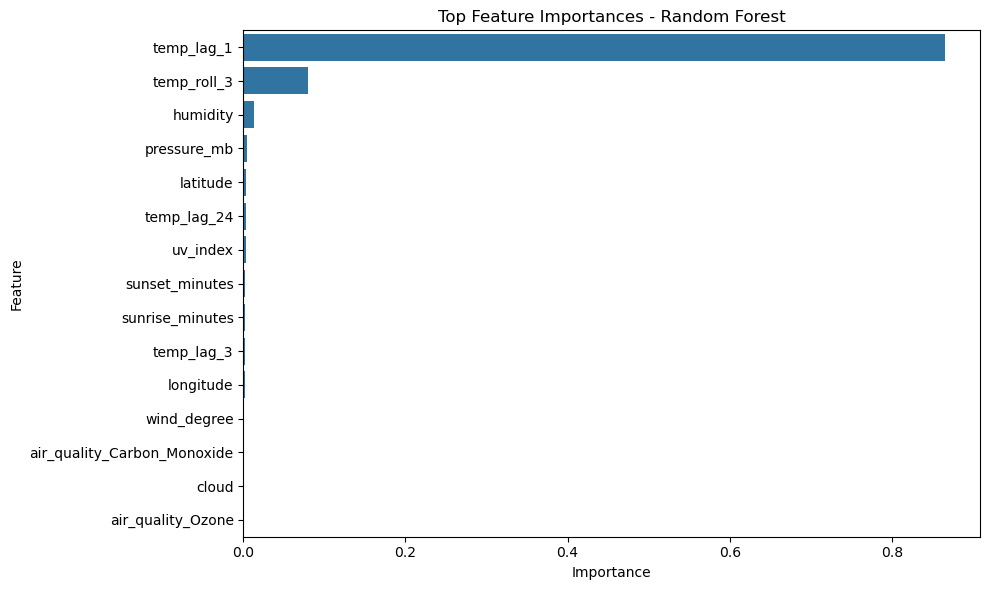

In [64]:
top_n = 15

top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
)

plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Spatial Analysis

### TEMPERATURE VS LATITUDE

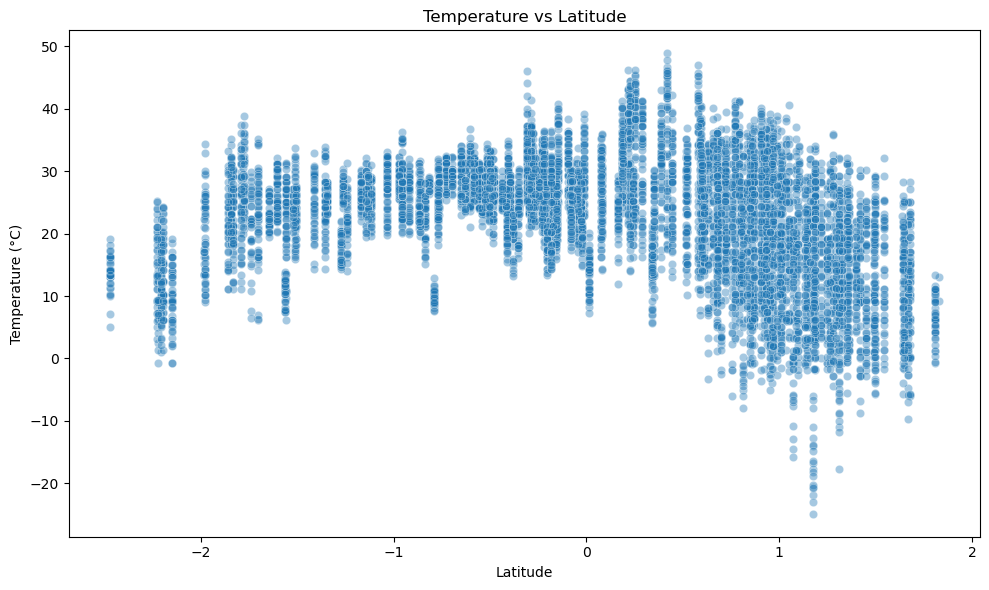

In [65]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df.sample(10000, random_state=42),
    x="latitude",
    y="temperature_celsius",
    alpha=0.4,
)

plt.title("Temperature vs Latitude")
plt.xlabel("Latitude")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

### AVG TEMPERATURE BY COUNTRY

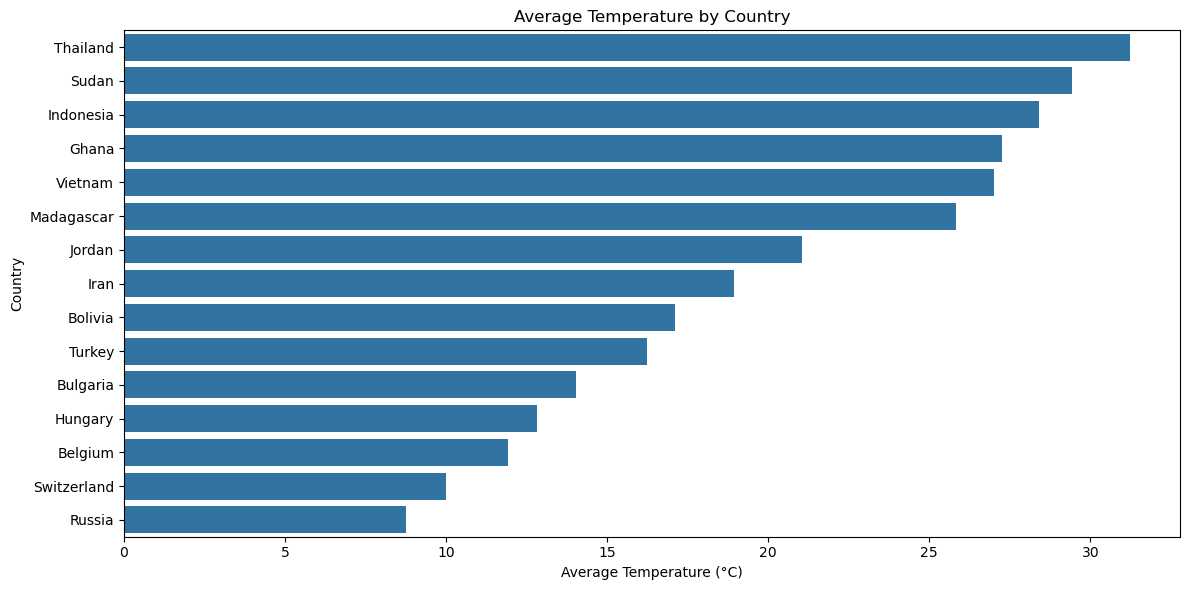

In [66]:
top_countries = (
    df["country"]
    .value_counts()
    .head(15)
    .index
)

country_temp = (
    df[df["country"].isin(top_countries)]
    .groupby("country")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=country_temp.values,
    y=country_temp.index,
)

plt.title("Average Temperature by Country")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### AIR QUALITY VS TEMPERATURE

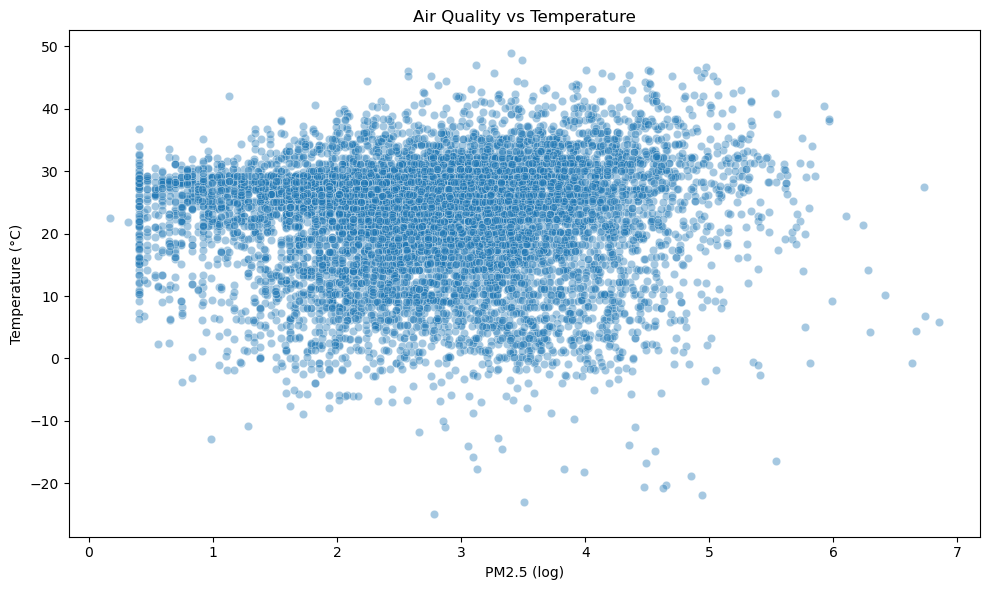

In [67]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train_df.sample(10000, random_state=42),
    x="air_quality_PM2.5_log",
    y="temperature_celsius",
    alpha=0.4,
)

plt.title("Air Quality vs Temperature")
plt.xlabel("PM2.5 (log)")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

### SPATIAL TEMPERATURE HEATMAP

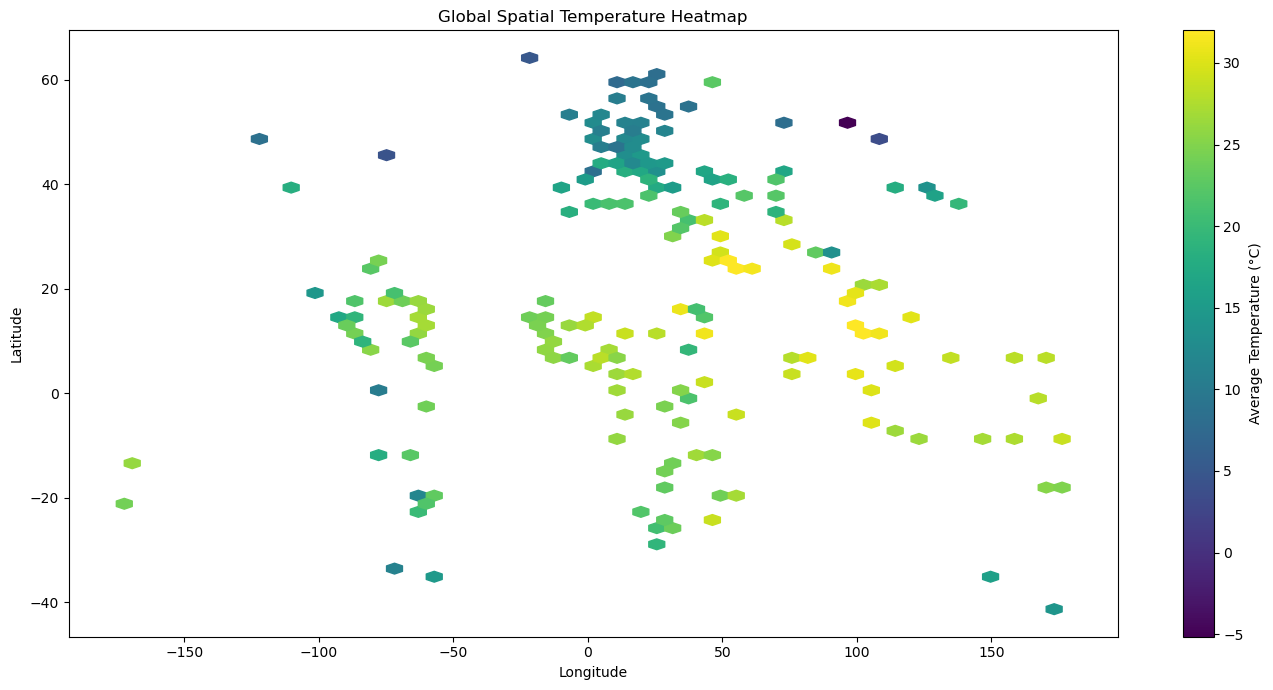

In [68]:
plt.figure(figsize=(14, 7))

hb = plt.hexbin(
    df["longitude"],
    df["latitude"],
    C=df["temperature_celsius"],
    reduce_C_function=np.mean,
    gridsize=60,
)

cb = plt.colorbar(hb)

cb.set_label("Average Temperature (°C)")

plt.title("Global Spatial Temperature Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

# Conclusions

This project explored the use of machine learning techniques to forecast weather temperature trends using the Global Weather Repository dataset. Throughout the analysis, significant attention was dedicated to data cleaning, preprocessing, feature engineering, exploratory analysis, and model evaluation.

Several preprocessing strategies were implemented, including:
- Temporal train-validation-test splitting
- Outlier and anomaly analysis
- Log transformations for highly skewed variables
- Feature scaling and normalization
- Cyclical encoding of temporal variables
- Lag and rolling window feature engineering

The exploratory analysis revealed strong temporal and geographical patterns in the data. Spatial visualizations showed clear climate distributions across different regions of the world, while correlation and feature importance analyses highlighted the strong influence of previous temperature observations on future forecasts.

Three forecasting models were evaluated:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

Among them, XGBoost achieved the best predictive performance, reaching the lowest prediction error and the highest coefficient of determination (R²). The results also demonstrated that lag-based features, especially recent temperature observations, were by far the most influential predictors in the forecasting task.

Overall, the project shows that combining careful preprocessing, temporal feature engineering, and ensemble-based machine learning models can produce highly accurate weather forecasting results.

## Future Work

Possible future improvements include:
- Exploring longer forecasting horizons
- Implementing deep learning architectures such as LSTMs or Transformers
- Incorporating real-time weather APIs
- Building region-specific forecasting models
- Extending the spatial analysis with interactive geographical visualizations